In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from calibration import load_data, separate_ch_sig, rectify, bandpass_filter, lowpass_filter

In [4]:
# to do:
# implement online filter difference equation here and test out the performance with a dataset

In [5]:
# bandpass filter parameters
b_b = [0.231, 0, -0.4626, 0, 0.231]
b_a = [1, -2.14, 1.553, -0.592, 0.1834]
b_gain = 0.2313
band_prevIn = [0, 0, 0, 0]
band_prevFilt = [0, 0, 0, 0]

In [6]:
# lowpass filter parameters
# l_b = [0.00313176, 0.00313176]
l_b = [9.82591682e-06, 1.96518336e-05, 9.82591682e-06]
# l_a = [1, -0.99373647]
l_a = [1., -1.99111429,  0.9911536]

low_prevIn = [0, 0]
low_prevFilt = [0, 0]

In [7]:
# load the raw and filtered data for comparison
dir = dir = r"C:\Users\Maryam\OneDrive - UW\Quals\stimActive-test\2025 - 10 - 24\modifiedMTS"
date_timestamp = "2025 - 10 - 24_11 - 18 - 32"
file_extension = ".csv"

_raw = r"\MTS_Test_RawFormattedEMGData_" + date_timestamp + file_extension
_filt = r"\MTS_Test_FiltEMGData_" + date_timestamp + file_extension
_env = r"\MTS_Test_EnvData_" + date_timestamp + file_extension

raw = pd.read_csv(dir + _raw)
rr_filt = pd.read_csv(dir + _filt)
rr_env = pd.read_csv(dir + _env)

In [8]:
rr_filt_emg1 = []
rr_env_emg1 = []
r_stim = []
r_thresh = []
for i, ch in enumerate(rr_filt["emg channel"]):
    if ch == 1:
        rr_filt_emg1.append(rr_filt["filt signal"][i])

for i, ch in enumerate(rr_env["emg channel"]):
    if ch == 1:
        rr_env_emg1.append(rr_env["enveloped signal"][i])
        r_stim.append(rr_env["stim command"][i])
        r_thresh.append(rr_env["threshold"][i])



In [9]:
filt = bandpass_filter(raw.EMG1)
low = lowpass_filter(rectify(filt), lowcut=2, order =2)

b:  [ 0.23130798  0.         -0.46261596  0.          0.23130798]
a:  [ 1.         -2.1400946   1.55288934 -0.59223286  0.18337778]
z: 0.23130797944426512
b:  [9.82591682e-06 1.96518336e-05 9.82591682e-06]
a:  [ 1.         -1.99111429  0.9911536 ]
z: 9.825916820482034e-06


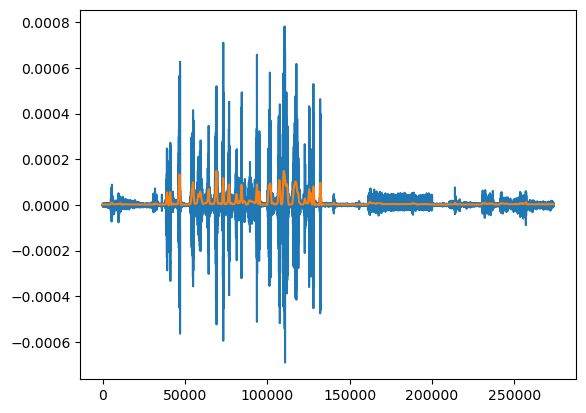

In [10]:
plt.plot(filt)
plt.plot(low)

In [11]:
# "online filter"
r_filt = []
b_gain = 0.9
for i, sig in enumerate(raw.EMG1):
    temp_filt = (b_gain*b_b[0]*sig + 
                  b_gain*b_b[1]*band_prevIn[0] + 
                  b_gain*b_b[2]*band_prevIn[1] + 
                  b_gain*b_b[3]*band_prevIn[2] +
                  b_gain*b_b[4]*band_prevIn[3] -
                  b_a[1]*band_prevFilt[0] - 
                  b_a[2]*band_prevFilt[1] -
                  b_a[3]*band_prevFilt[2] -
                  b_a[4]*band_prevFilt[3])
    r_filt.append(temp_filt)
    band_prevFilt.insert(0,temp_filt)
    band_prevFilt.pop()
    band_prevIn.insert(0, sig)
    band_prevIn.pop()




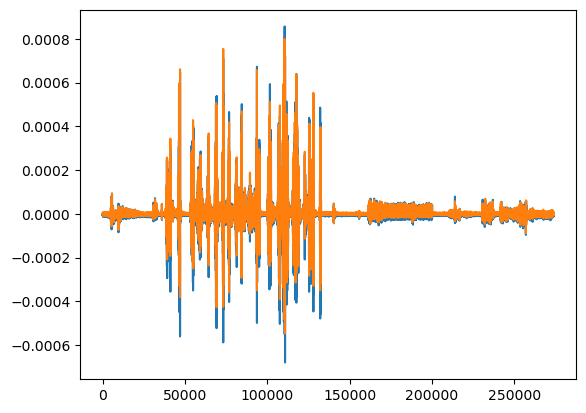

In [12]:
plt.plot(raw.EMG1)
plt.plot(r_filt)
plt.show()

In [13]:
r_env = []
l_gain = 2
for i, sig in enumerate(r_filt):
    rect_sig = rectify(sig)
    # temp_filt = (l_b[0]*rectify(sig) +
    #              l_b[1]*low_prevFilt[0]) / 10*(
    #              1 + l_a[1]*low_prevFilt[0]
    #              )
    temp_filt = l_gain*(l_b[0]*rect_sig +
                 l_b[1]*low_prevIn[0] + 
                 l_b[2]*low_prevIn[1]) - (
                 l_a[1]*low_prevFilt[0] + 
                 l_a[2]*low_prevFilt[1]   
                 )
    
    r_env.append(temp_filt)
    low_prevFilt.insert(0, temp_filt)
    low_prevFilt.pop()
    low_prevIn.insert(0, rect_sig)
    low_prevIn.pop()

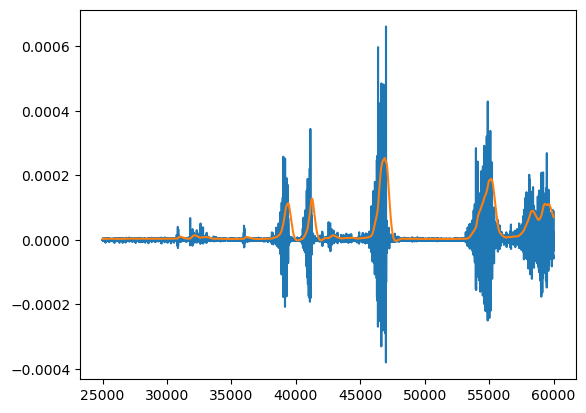

In [17]:
# plt.plot(raw.EMG1)
# plt.plot(r_filt)
# plt.plot(r_env)
low = 25000
high = 60000
# high = len(raw.EMG1)
plt.plot(np.arange(low,high), r_filt[low:high])
plt.plot(np.arange(low,high), r_env[low:high])


# plt.ylim([0,0.0001])
plt.show()

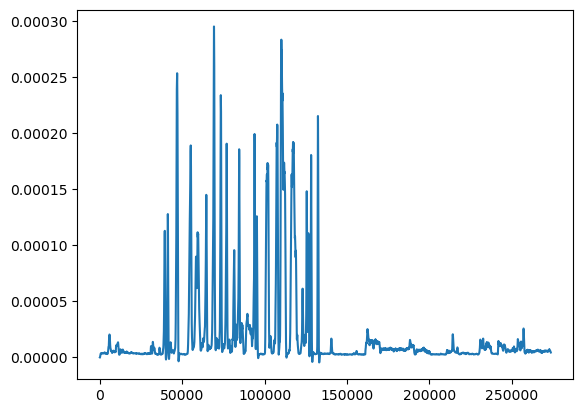

In [15]:
plt.plot(r_env)